In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
from sklearn.compose import ColumnTransformer
import copy
import os
import pickle

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\Exercise2


In [2]:
cc_train = pd.read_csv("datasets/creditcard_train_balanced.csv")
cc_test = pd.read_csv("datasets/creditcard_test.csv")

cc_train = cc_train.drop("ID", axis = 1)
cc_test = cc_test.drop("ID", axis = 1)

In [3]:
def get_dummies_all(X_train, X_test):
    """
    Converts all categorical variables in a DataFrame into dummy (one-hot encoded) variables.
    """
    categorical_cols = ["MARRIAGE", "SEX", "EDUCATION"]  # Select categorical columns
    X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
    return X_train_encoded, X_test_encoded

In [4]:
X_train = cc_train.drop('default.payment.next.month', axis = 1)
X_test = cc_test.drop('default.payment.next.month', axis = 1)
y_train = cc_train['default.payment.next.month']
y_test = cc_test['default.payment.next.month']

X_train, X_test = get_dummies_all(X_train, X_test)

In [5]:
numeric_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
]

ordinal_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("ord", StandardScaler(), ordinal_features)
    ],
    remainder="passthrough"
)

X_train_sc = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

X_test_sc = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

In [7]:
print(X_test_sc.head())

   num__LIMIT_BAL  num__AGE  num__BILL_AMT1  num__BILL_AMT2  num__BILL_AMT3  \
0       -0.987556 -1.130032       -0.560318       -0.537604       -0.500551   
1       -0.032636 -1.023458        1.167285        1.075205        1.005809   
2       -0.669249 -0.384010        0.267302        0.285872        0.315655   
3       -0.191789  1.427759       -0.400706       -0.413506       -0.434752   
4       -0.828403  0.042289        0.592984       -0.013349       -0.059405   

   num__BILL_AMT4  num__BILL_AMT5  num__BILL_AMT6  num__PAY_AMT1  \
0       -0.468747       -0.431035       -0.403684      -0.227715   
1        0.910961        0.613932        0.644591      -0.024610   
2        0.417558        0.489401        0.526191      -0.164389   
3       -0.401808       -0.471511       -0.536053      -0.220233   
4       -0.360325       -0.323657       -0.326267      -0.193706   

   num__PAY_AMT2  ...  ord__PAY_5  ord__PAY_6  remainder__MARRIAGE_2  \
0      -0.148541  ...    0.083167    0.11085

### Fit the model

In [8]:
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Prediction and utility

In [9]:
print("Training set: ")
fc.predict_binary(model, X_train_sc, y_train, conf_matrix=False)

Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6830
Recall: 0.6438
F1 Score: 0.6628
---------------------------------------


---------------------------------------
Accuracy: 0.6900
Precision: 0.3788
Recall: 0.6512
F1 Score: 0.4790
---------------------------------------
          Predicted 0  Predicted 1
Actual 0         3285         1402
Actual 1          458          855


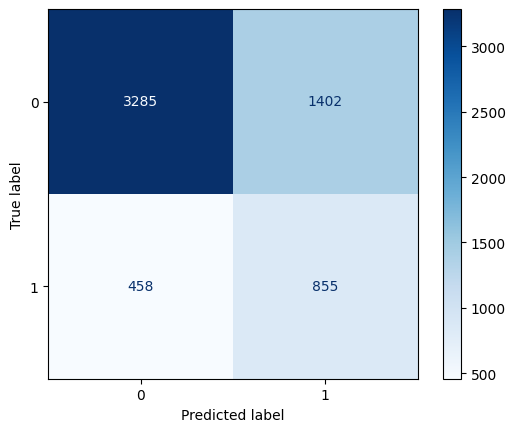

Saved results to results/model_results_cc.xlsx


In [10]:
fc.predict_binary_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original",
    epsilon=0,
    output_file="results/model_results_cc.xlsx"
)

In [11]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = True)

Accuracy: 0.6719
Precision: 0.6822
Recall: 0.6436
F1 Score: 0.6623
Time: 2.3403542041778564


{'fit_time': array([0.2237916 , 0.19525313, 0.20115876, 0.23466706, 0.24696946,
        0.24189878, 0.2092042 , 0.21199989, 0.21755576, 0.2033906 ]),
 'score_time': array([0.01154447, 0.01163673, 0.01184511, 0.0125041 , 0.02190638,
        0.01207089, 0.01156211, 0.01993227, 0.01051044, 0.01147056]),
 'test_accuracy': array([0.6753212 , 0.66729122, 0.67103854, 0.66836188, 0.67550201,
        0.68487282, 0.66746988, 0.67657296, 0.67202142, 0.66024096]),
 'test_precision': array([0.68144044, 0.67745599, 0.68586387, 0.67599328, 0.69007545,
        0.6978211 , 0.67705382, 0.68728717, 0.67811634, 0.67124071]),
 'test_recall': array([0.65845824, 0.63865096, 0.63115632, 0.64668094, 0.63685056,
        0.65184788, 0.64006427, 0.64828694, 0.65524625, 0.62847966]),
 'test_f1': array([0.66975225, 0.6574814 , 0.65737385, 0.66101231, 0.66239554,
        0.67405151, 0.65803965, 0.66721763, 0.66648516, 0.64915676])}

In [12]:
fc.hyperparameterTuning_save_Results(X_train_sc, y_train, cv=10, bivariate = True, perturbation_type="Original_hpt_balanced",
        epsilon=0, output_file="results/model_results_cc.xlsx")

Best parameters: {'C': 0.01}
Accuracy : 0.6737
Precision: 0.6855
Recall   : 0.6421
F1 Score : 0.6630
Time     : 11.32 s


(LogisticRegression(C=0.01, max_iter=1000), {'C': 0.01})

In [13]:
X_all = pd.concat([X_train_sc, X_test_sc], axis=0)
orig_confidence_scores = model.predict_proba(X_all)

with open("orig_confidence_scores_creditcard_balanced.pkl", "wb") as f:
    pickle.dump(orig_confidence_scores, f)

----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

### Perturb dataset

In [14]:
print(X_train.columns)

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'MARRIAGE_2', 'MARRIAGE_3', 'SEX_2',
       'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5',
       'EDUCATION_6'],
      dtype='object')


In [15]:
ranges = [[1000,1000000], [18,100], [-2,8], [-2,8], [-2,8], [-2,8], [-2,8],
       [-2,8], [-10000,500000], [-10000,500000], [-10000,500000], [-10000,500000],
       [-10000,500000],[-10000,500000], [0,250000], [0,250000], [0,250000],
       [0,250000], [0,250000], [0,250000], [0,1], [0,1], [0,1],
       [0,1], [0,1], [0,1], [0,1], [0,1]]
print(ranges)

sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)


[[1000, 1000000], [18, 100], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]]
[999000, 82, 10, 10, 10, 10, 10, 10, 510000, 510000, 510000, 510000, 510000, 510000, 250000, 250000, 250000, 250000, 250000, 250000, 1, 1, 1, 1, 1, 1, 1, 1]


In [16]:
X_train_clipped = X_train.copy()
for i, col in enumerate(X_train.columns):
    lower, upper = ranges[i]
    X_train_clipped[col] = X_train_clipped[col].clip(lower=lower, upper=upper)

In [17]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train_clipped.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train_clipped.columns):
        eps_j = e # The paper uses eps_j = e/d, but this leades to huge errors
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train_clipped))

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [18]:
input_confidence_scores = {}

for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input_balanced",
        epsilon=e,
        output_file="results/model_results_cc.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = True, perturbation_type="Input_hpt_balanced",
        epsilon=e, output_file="results/model_results_cc.xlsx")

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train_sc, X_test_sc], axis=0)
    input_confidence_scores[e] = input_model.predict_proba(X_all)

with open("input_confidence_scores_creditcard_balanced.pkl", "wb") as f:
    pickle.dump(input_confidence_scores, f)


Training set: 
---------------------------------------
Accuracy: 0.5145
Precision: 0.5145
Recall: 0.5142
F1 Score: 0.5143
---------------------------------------
---------------------------------------
Accuracy: 0.7815
Precision: 0.6667
Recall: 0.0030
F1 Score: 0.0061
---------------------------------------
Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5081
Precision: 0.5081
Recall   : 0.5085
F1 Score : 0.5083
Time     : 0.67 s
Training set: 
---------------------------------------
Accuracy: 0.5379
Precision: 0.5386
Recall: 0.5290
F1 Score: 0.5338
---------------------------------------
---------------------------------------
Accuracy: 0.7642
Precision: 0.4431
Recall: 0.3024
F1 Score: 0.3594
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5356
Precision: 0.5362
Recall   : 0.5273
F1 Score : 0.5317
Time     : 0.63 s
Training set: 
---------------------------------------
Accuracy: 0.6067
Precision: 0.6142
Recall: 0.5741
F1 Score: 0.5935
---------------------------------------
---------------------------------------
Accuracy: 0.6640
Precision: 0.3488
Recall: 0.6177
F1 Score: 0.4458
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.1}
Accuracy : 0.6061
Precision: 0.6135
Recall   : 0.5740
F1 Score : 0.5931
Time     : 0.74 s
Training set: 
---------------------------------------
Accuracy: 0.6345
Precision: 0.6448
Recall: 0.5990
F1 Score: 0.6211
---------------------------------------
---------------------------------------
Accuracy: 0.6172
Precision: 0.3234
Recall: 0.6862
F1 Score: 0.4396
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 1}
Accuracy : 0.6329
Precision: 0.6431
Recall   : 0.5974
F1 Score : 0.6194
Time     : 0.89 s
Training set: 
---------------------------------------
Accuracy: 0.6601
Precision: 0.6724
Recall: 0.6244
F1 Score: 0.6475
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


---------------------------------------
Accuracy: 0.6315
Precision: 0.3361
Recall: 0.7014
F1 Score: 0.4545
---------------------------------------
Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.6598
Precision: 0.6725
Recall   : 0.6234
F1 Score : 0.6470
Time     : 1.09 s
Training set: 
---------------------------------------
Accuracy: 0.6656
Precision: 0.6775
Recall: 0.6319
F1 Score: 0.6539
---------------------------------------
---------------------------------------
Accuracy: 0.6560
Precision: 0.3529
Recall: 0.6862
F1 Score: 0.4661
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 10}
Accuracy : 0.6647
Precision: 0.6766
Recall   : 0.6317
F1 Score : 0.6533
Time     : 1.24 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Training set: 
---------------------------------------
Accuracy: 0.6695
Precision: 0.6806
Recall: 0.6389
F1 Score: 0.6591
---------------------------------------
---------------------------------------
Accuracy: 0.6758
Precision: 0.3677
Recall: 0.6687
F1 Score: 0.4745
---------------------------------------
Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.1}
Accuracy : 0.6698
Precision: 0.6811
Recall   : 0.6387
F1 Score : 0.6592
Time     : 1.69 s


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [19]:
n = X_train.shape[0]
#C_x = np.max(np.linalg.norm(X_train, axis=1))
lambda_reg = 1 / model.C
sensitivity = (2) / (lambda_reg * n)

epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity / e,size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity / 3,size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [20]:
output_confidence_scores = {}

for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output_balanced",
        epsilon=e,
        output_file="results/model_results_cc.xlsx"
    )

    #NEEDED FOR THE MEMBERSHIP ATTACK
    X_all = pd.concat([X_train_sc, X_test_sc], axis=0)
    output_confidence_scores[e] = output_model.predict_proba(X_all)

with open("output_confidence_scores_creditcard_balanced.pkl", "wb") as f:
    pickle.dump(output_confidence_scores, f)

Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6831
Recall: 0.6437
F1 Score: 0.6628
---------------------------------------
---------------------------------------
Accuracy: 0.6895
Precision: 0.3782
Recall: 0.6504
F1 Score: 0.4783
---------------------------------------
Saved results to results/model_results_cc.xlsx
Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6829
Recall: 0.6438
F1 Score: 0.6628
---------------------------------------
---------------------------------------
Accuracy: 0.6897
Precision: 0.3784
Recall: 0.6504
F1 Score: 0.4784
---------------------------------------
Saved results to results/model_results_cc.xlsx
Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6830
Recall: 0.6438
F1 Score: 0.6628
---------------------------------------
---------------------------------------
Accuracy: 0.6898
Precision: 0.3787
Recall: 0.6512
F1 Score: 0.4789
-------------------

----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [21]:
data_norm = np.max(np.linalg.norm(np.asarray(X_train_sc), axis=1))
print("data_norm (max L2 norm of a scaled training row):", data_norm)


data_norm (max L2 norm of a scaled training row): 108.35069385660655


In [22]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]

internal_models = fc.internal_perturbation_save_results(
    "creditcard",
    X_train_sc,
    y_train,
    X_test_sc,
    y_test,
    epsilon_values=epsilon_values,
    data_norm=data_norm,
    C=model.C,
    bivariate=True,
    output_file="results/model_results_cc.xlsx",
    perturbation_type="Internal_balanced"
)



---------------------------------------
Epsilon: 0.1
Accuracy: 0.5942
Precision: 0.2386
Recall: 0.3899
F1 Score: 0.2960
Time: 0.06 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 1
Accuracy: 0.5947
Precision: 0.2646
Recall: 0.4791
F1 Score: 0.3409
Time: 0.24 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 5
Accuracy: 0.6397
Precision: 0.3238
Recall: 0.5941
F1 Score: 0.4191
Time: 0.54 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 10
Accuracy: 0.6477
Precision: 0.3329
Recall: 0.6078
F1 Score: 0.4302
Time: 1.09 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 30
Accuracy: 0.6888
Precision: 0.3757
Recall: 0.6375
F1 Score: 0.4727
Time: 0.65 s
---------------------------------------


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


---------------------------------------
Epsilon: 50
Accuracy: 0.6870
Precision: 0.3745
Recall: 0.6420
F1 Score: 0.4731
Time: 0.25 s
---------------------------------------
---------------------------------------
Epsilon: 100
Accuracy: 0.6905
Precision: 0.3788
Recall: 0.6474
F1 Score: 0.4779
Time: 0.19 s
---------------------------------------
Saved results to results/model_results_cc.xlsx


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
